$$
\begin{array}{c}
{\Huge \text{CAUSAL INFERENCE LAB 2}}\\\\
{\Large \textbf{Abhishek Bakshi}} \\
{\large \textit{Center for Data Science, New York University}} \\\\\
{\Large \text{Office Hours: Wednesdays, 12:30 - 1:30 pm}} \\
{\Large \textit{Room 242, 60 5th Ave, 2nd floor}} \\\\
\text{Materials prepared by: Abhishek Bakshi, Xiang Gao}
\end{array}
$$

---

<p align="center">
    <img
      src="https://imgs.xkcd.com/comics/prediction.png"
      alt="xkcd: Prediction"
      width="800"
    >
</p>

<h1 style="font-size: 42px;">Probability Review</h1>

---

<h1 style="font-size: 30px;">Today's Goals:</h1>

<ol style="font-size: 20px; line-height: 1.6;">
  <li>Build and check PMFs and PDFs</li>
  <li>Recognize common discrete and continuous distributions</li>
  <li>Work with joint and marginal distributions</li>
  <li>Calculate probabilities, expectation, and variance</li>
  <li>Interpret covariance, correlation, independence, and causation</li>
</ol>

---

<style>
/* Large, consistent classroom typography for rendered Markdown. */
body,
.jp-RenderedHTMLCommon,
.jp-RenderedMarkdown,
.markdown-body,
.vscode-body {
  font-family: Arial, Helvetica, sans-serif !important;
}

p, li, blockquote, td, th {
  font-size: 20px !important;
  line-height: 1.6 !important;
}

h1 {
  font-family: Arial, Helvetica, sans-serif !important;
  font-size: 42px !important;
  line-height: 1.25 !important;
  margin-top: 0.6em !important;
}

h2 {
  font-family: Arial, Helvetica, sans-serif !important;
  font-size: 30px !important;
  line-height: 1.3 !important;
  margin-top: 0.7em !important;
  border-bottom: 2px solid #4b4bb7;
  padding-bottom: 0.15em;
}

h3 {
  font-family: Arial, Helvetica, sans-serif !important;
  font-size: 25px !important;
  line-height: 1.35 !important;
  margin-top: 0.7em !important;
}

h4 {
  font-family: Arial, Helvetica, sans-serif !important;
  font-size: 22px !important;
  line-height: 1.4 !important;
}

table {
  font-size: 19px !important;
  line-height: 1.45 !important;
}

code, pre {
  font-size: 17px !important;
}

blockquote {
  border-left: 5px solid #4b4bb7 !important;
  padding: 0.3em 0.8em !important;
  color: inherit !important;
}

.MathJax, mjx-container {
  font-size: 115% !important;
}
</style>

In [ ]:
# !pip install math scipy

In [44]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Wedge
from scipy import stats

pd.set_option("display.precision", 4)
plt.rcParams.update({
    "font.size": 15, "axes.titlesize": 19, "axes.labelsize": 16,
    "xtick.labelsize": 13, "ytick.labelsize": 13,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.constrained_layout.use": True,
})
print("Ready for probability review!")


Ready for probability review!


## 1. Discrete Random Variables

---

### Probability Mass Function (PMF)

For a discrete random variable $X$, a PMF (*probability mass function*) characterized by $P(X = x)$ assigns a probability to each possible observed value ($x$).

Conditions for a valid PMF:

1. $0\leq P(X=x)\leq1$ for every possible value/outcome $x$.
2. $\sum_{x\in\mathcal X}P(X=x)=1$, where $\mathcal X$ is the support.

<!-- Values **inside the support** have positive probability. Values outside it have probability 0. -->

<!-- > The sum-to-one rule has a continuous analogue: total **area** under a PDF is 1. -->

### Example 1: Loaded die

Let $X$ be the outcome of a loaded die. A weight lies symmetrically off-center toward face 1, such that

- the probability of rolling a 6 is **twice** that of rolling a 1
- the probability of rolling any other outcome ({2, 3, 4, 5}) is **1.5 times** that of rolling a 1

What is the PMF? *Hint: Let $P(X=1)=a$.*

,Face (x),P(X = x)
0,1,0.1111
1,2,0.1667
2,3,0.1667
3,4,0.1667
4,5,0.1667
5,6,0.2222


a = 0.111
All probabilities lie in [0, 1]: True
Total probability: 1.000


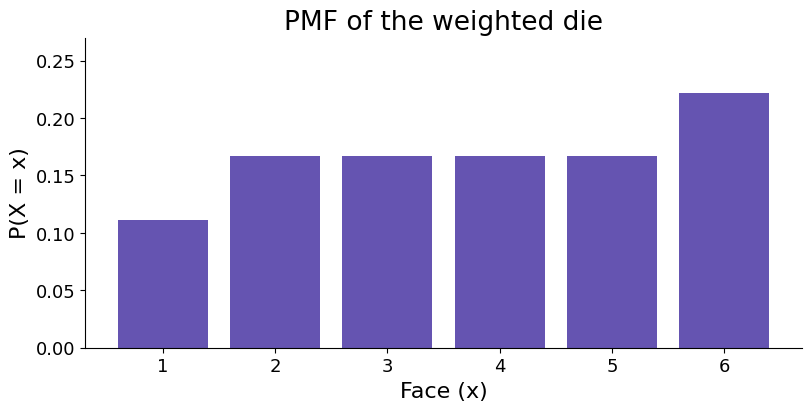

In [ ]:
# Question 1 solution
faces = np.arange(1, 7)
# a = 
weighted_pmf = np.array([a, 1.5*a, 1.5*a, 1.5*a, 1.5*a, 2*a])

display(pd.DataFrame({"Face (x)": faces, "P(X = x)": weighted_pmf}))
print(f"a = {a:.3f}")
print(f"All probabilities lie in [0, 1]: {np.all((weighted_pmf >= 0) & (weighted_pmf <= 1))}")
print(f"Total probability: {weighted_pmf.sum():.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(faces, weighted_pmf, color="#6554B1")
ax.set(title="PMF of the weighted die", xlabel="Face (x)", ylabel="P(X = x)", xticks=faces, ylim=(0, 0.27))
plt.show()


### Common discrete distributions

| Distribution | PMF / support | Real-life example |
|---|---|---|
| Bernoulli($p$) | $P(X=x)=p^x(1-p)^{1-x}$, $x\in\{0,1\}$ | Indicator that GPA is at least 3.5 |
| Binomial($n,p$) | $P(X=k)=\binom nkp^k(1-p)^{n-k}$, $k=0,\ldots,n$ | Number of heads in $n$ coin flips |
| Poisson($\lambda$) | $P(X=k)=e^{-\lambda}\lambda^k/k!$, $k=0,1,\ldots$ | Number of course-forum posts in a day |
| Geometric($p$) | $P(X=k)=(1-p)^{k-1}p$, $k=1,2,\ldots$ | Darts thrown until the first bulls-eye |

**Questions:** 
- Which distribution has infinite support?
- The support of which distribution starts at 1?

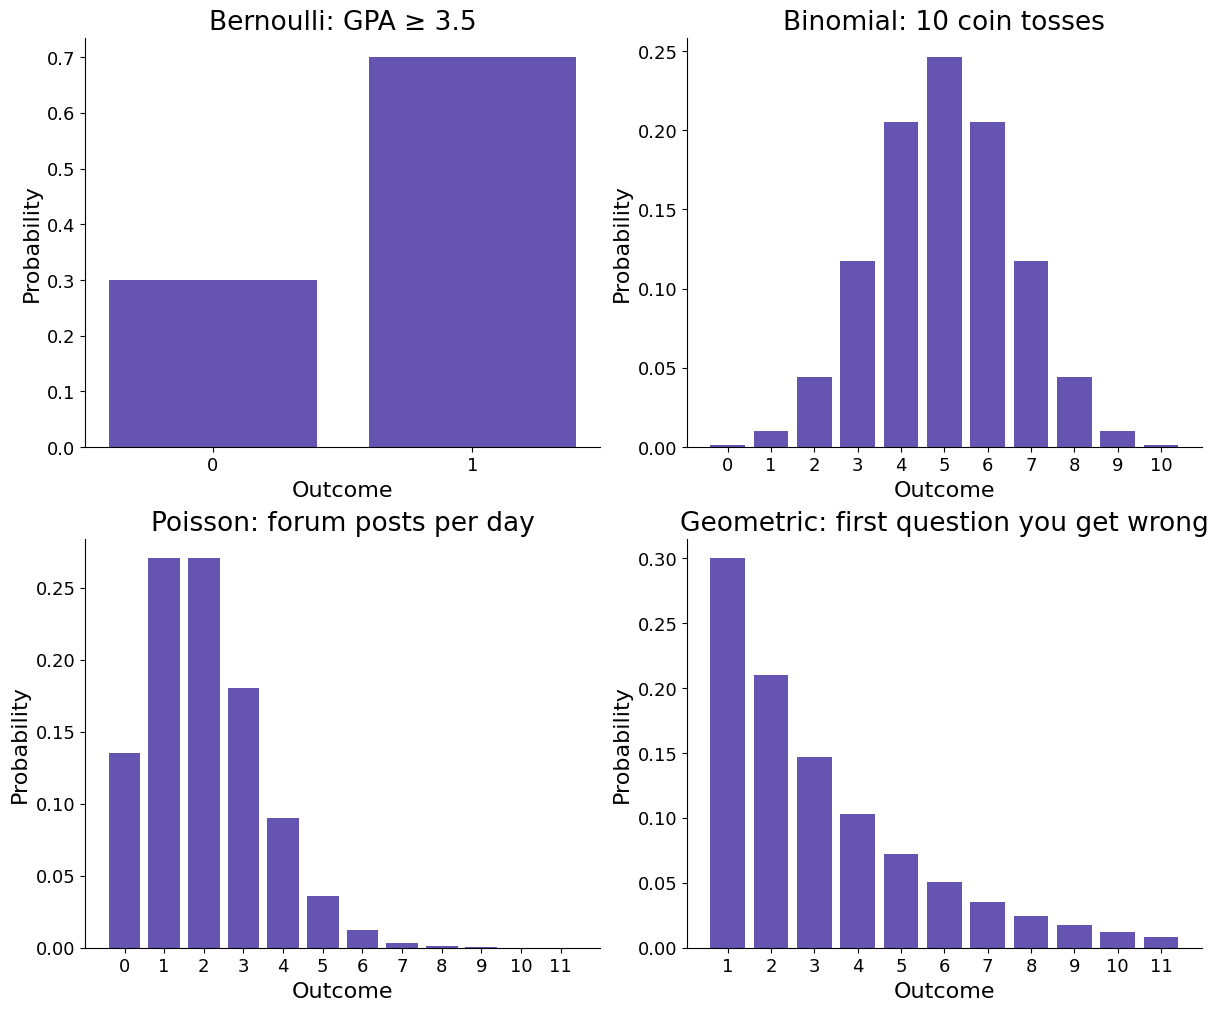

In [ ]:
discrete_models = [
    ("Bernoulli: GPA ≥ 3.5", stats.bernoulli(0.7), np.arange(0, 2)),
    ("Binomial: 10 coin tosses", stats.binom(10, 0.5), np.arange(0, 11)),
    ("Poisson: forum posts per day", stats.poisson(2), np.arange(0, 12)),
    ("Geometric: darts thrown until first bullseye", stats.geom(0.3), np.arange(1, 12)),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (title, model, support) in zip(axes.flat, discrete_models):
    ax.bar(support, model.pmf(support), color="#6554B1")
    ax.set(title=title, xlabel="Outcome", ylabel="Probability")
    ax.set_xticks(support)
plt.show()


### Example 2: Lab attendance

Suppose 20 students independently attend lab with the same probability $p=0.7$. Let $X$ be the number who attend.

1. What distribution does $X$ have?
2. Find $P(X=18)$.
3. Find $P(X\geq18)$.

P(exactly 18 attend) = 0.0278
P(at least 18) = 0.0355
P(exactly 18 attend) = 0.0278
P(at least 18), adding 18, 19, 20 = 0.0355


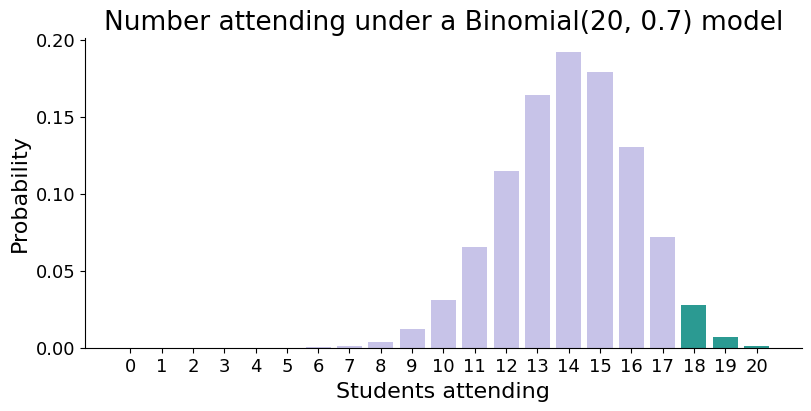

In [19]:
# Question 2 solution
n_students = 20
p_attend = 0.7
k = 18

## Define the Binomial PMF function
def binomial_pmf(k: int, n: int=n_students, p: float=p_attend) -> float:
    """
    Calculate the pmf at k for Binomial(n, p)
    """
    return math.comb(n, k) * p ** k * (1 - p) ** (n - k)

## Calculate PMF at 18
print(f"P(exactly 18 attend) = {binomial_pmf(k):.4f}")
print(f"P(at least 18) = {sum([binomial_pmf(i) for i in range(k, n_students + 1)]):.4f}")

## Using stats.binom function
attendance = stats.binom(n_students, p_attend)
exactly_k = attendance.pmf(k)
at_least_k_sum = sum([attendance.pmf(i) for i in range(k, n_students + 1)])

print(f"P(exactly 18 attend) = {exactly_k:.4f}")
print(f"P(at least 18), adding 18, 19, 20 = {at_least_k_sum:.4f}")

support = np.arange(n_students + 1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(support, attendance.pmf(support), color=np.where(support >= k, "#2B9A92", "#C7C3E8"))
ax.set_xticks(support)
ax.set(title="Number attending under a Binomial(20, 0.7) model", xlabel="Students attending", ylabel="Probability")
plt.show()


## 2. Continuous Random Variables

---

### Probability density function (PDF) and Cumulative distribution function (CDF)

For a continuous random variable $X$ with PDF $f(x)$:

1. $f(x)\geq0$ for all $x$.
2. $\int_{-\infty}^{\infty}f(x)\,dx=1$.
3. $P(a<X<b)=\int_a^b f(x)\,dx$ is an **area**.
4. $P(X=x)=0$ at every single point.

The CDF is $F(x)=P(X\leq x) =\int_{-\infty}^x f(x)dx$. It satisfies:

1. $0\leq F(x)\leq1$.
2. It is nondecreasing and right-continuous.
3. $F(x)\to0$ as $x\to-\infty$ and $F(x)\to1$ as $x\to\infty$.

For a continuous variable, $P(a<X\leq b)=F(b)-F(a)$.

### Example 3: Uniform spinner

Imagine a circular spinner like a clock, with a red needle that can rotate freely. Let $\Theta$ be its final angle, measured from 0 to 360 degrees.

$$\Theta\sim\mathrm{Uniform}(0,360),\qquad f_\Theta(\theta)=\frac{1}{360}.$$



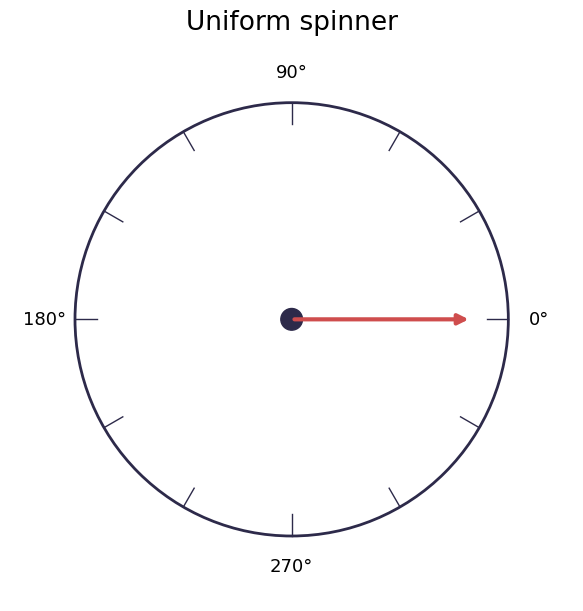

In [24]:
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"aspect": "equal"})
ax.add_patch(Circle((0, 0), 1, fill=False, lw=2, color="#2D2A4A"))
for angle in range(0, 360, 30):
    radians = np.deg2rad(angle)
    ax.plot([0.90*np.cos(radians), np.cos(radians)], [0.90*np.sin(radians), np.sin(radians)], color="#2D2A4A", lw=1)
for angle, label in [(0, "0°"), (90, "90°"), (180, "180°"), (270, "270°")]:
    radians = np.deg2rad(angle)
    ax.text(1.14*np.cos(radians), 1.14*np.sin(radians), label, ha="center", va="center", fontsize=13)
needle_angle = 0
radians = np.deg2rad(needle_angle)
ax.annotate("", xy=(0.83*np.cos(radians), 0.83*np.sin(radians)), xytext=(0, 0), arrowprops={"arrowstyle": "-|>", "color": "#CF4D4D", "lw": 3})
ax.add_patch(Circle((0, 0), 0.05, color="#2D2A4A"))
ax.set(title="Uniform spinner", xlim=(-1.3, 1.3), ylim=(-1.3, 1.3))
ax.axis("off")
plt.show()

#### Question: What is the probability of the spinner landing anywhere between $75^\circ$ and $105^\circ$?

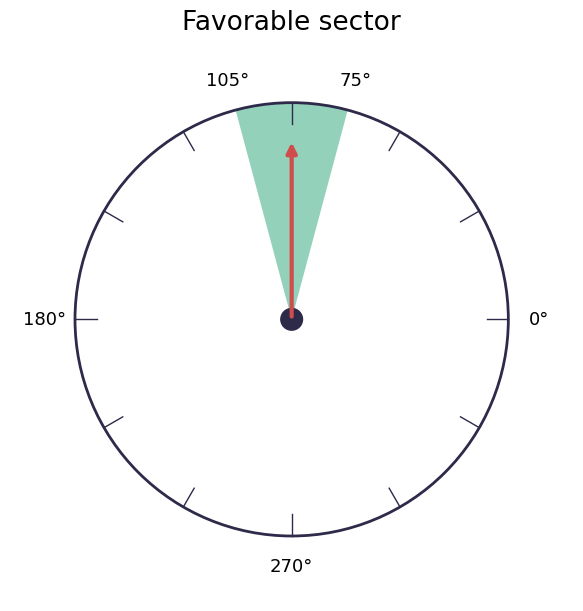

P(75 < Θ < 105) = 30/360 = 0.0833


In [47]:
# Question 3 solution: a clock-like spinner and the favorable sector
lower, upper = 75, 105
spinner_probability = (upper - lower) / 360

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"aspect": "equal"})
ax.add_patch(Wedge((0, 0), 1, lower, upper, facecolor="#59B997", alpha=0.65, label=f"Favorable sector: {upper-lower} degrees"))
ax.add_patch(Circle((0, 0), 1, fill=False, lw=2, color="#2D2A4A"))
for angle in range(0, 360, 30):
    radians = np.deg2rad(angle)
    ax.plot([0.90*np.cos(radians), np.cos(radians)], [0.90*np.sin(radians), np.sin(radians)], color="#2D2A4A", lw=1)
for angle, label in [(0, "0°"), (75, "75°"), (105, "105°"), (180, "180°"), (270, "270°")]:
    radians = np.deg2rad(angle)
    ax.text(1.14*np.cos(radians), 1.14*np.sin(radians), label, ha="center", va="center", fontsize=13)
needle_angle = 90
radians = np.deg2rad(needle_angle)
ax.annotate("", xy=(0.83*np.cos(radians), 0.83*np.sin(radians)), xytext=(0, 0), arrowprops={"arrowstyle": "-|>", "color": "#CF4D4D", "lw": 3})
ax.add_patch(Circle((0, 0), 0.05, color="#2D2A4A"))
ax.set(title="Favorable sector", xlim=(-1.3, 1.3), ylim=(-1.3, 1.3))
ax.axis("off")
plt.show()
print(f"P({lower} < Θ < {upper}) = {upper-lower}/360 = {spinner_probability:.4f}")


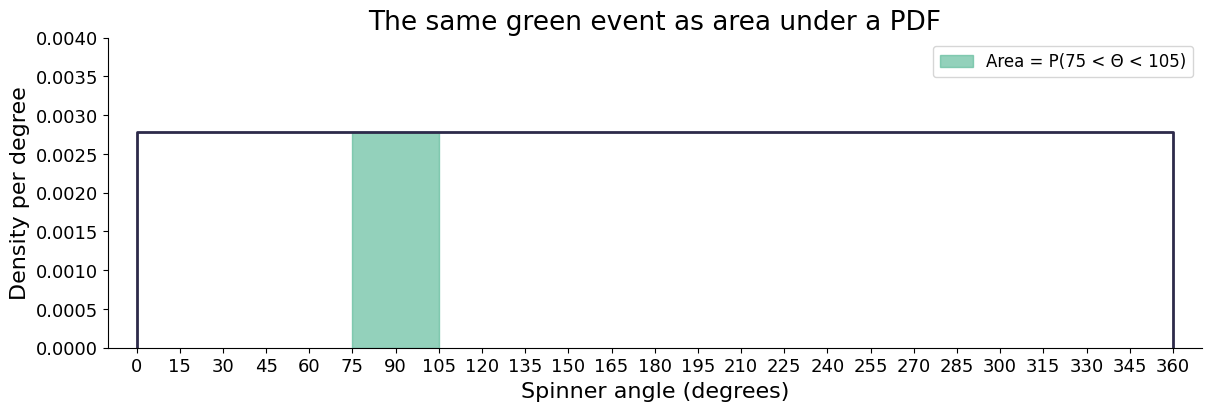

CDF calculation: 0.0833


In [32]:
# The same answer is green area under the uniform PDF
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot([0, 0, 360, 360], [0, 1/360, 1/360, 0], color="#2D2A4A", lw=2)
ax.fill_between([lower, upper], 1/360, color="#59B997", alpha=0.65, label=f"Area = P({lower} < Θ < {upper})")
ax.set(title="The same green event as area under a PDF",
       xlabel="Spinner angle (degrees)", ylabel="Density per degree",
       xlim=(-10, 370), ylim=(0, 0.004))
ax.set_xticks([15 * i for i in range(25)])
ax.legend(fontsize=12)
plt.show()
uniform_spinner = stats.uniform(loc=0, scale=360)
print(f"CDF calculation: {uniform_spinner.cdf(upper) - uniform_spinner.cdf(lower):.4f}")


### Common continuous distributions

| Distribution | PDF / support | Real-life example |
|---|---|---|
| Uniform | Constant density on $[a,b]$ | An ideal spinner angle |
| Normal | Symmetric bell curve on all real numbers | Approximate variation in commute time |
| Exponential | $f(x)=\lambda e^{-\lambda x}$ for $x\geq0$ | Waiting time until the next shuttle under a constant-rate model |
| Pareto | Heavy right tail for $x\geq x_m$ | A few online study resources receive far more views than most |

The “80/20 rule” is intuition for Pareto-like concentration: a small fraction of items can account for a large fraction of activity. It is not a fixed rule every Pareto distribution obeys exactly.

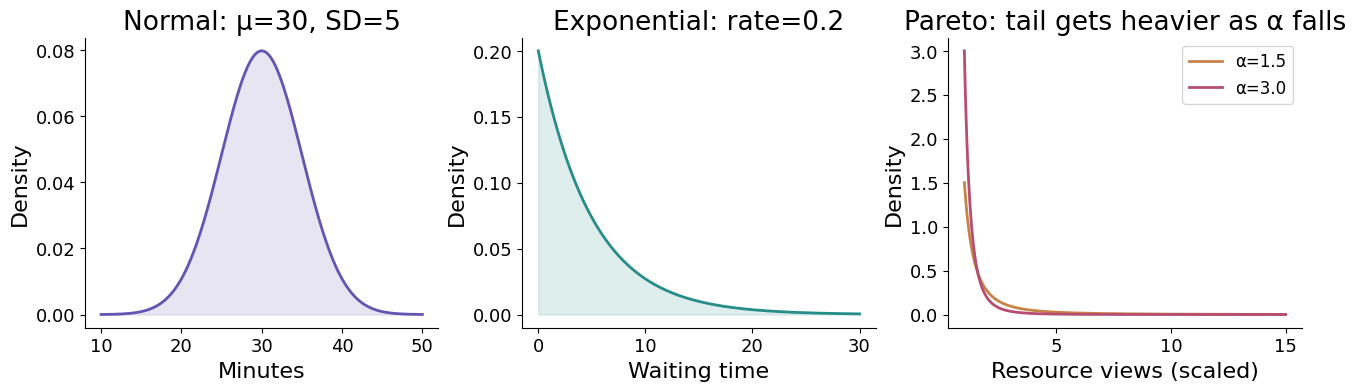

In [ ]:
# Vary normal_sd or arrival_rate, predict, then rerun.
normal_mean = 30
normal_sd = 5
arrival_rate = 0.2  # Events per minute; mean waiting time is 1 / rate = 5 minutes.
normal_model = stats.norm(loc=normal_mean, scale=normal_sd)
exponential_model = stats.expon(scale=1 / arrival_rate)

# Pareto uses shape alpha and minimum xm. Smaller alpha gives a heavier tail.
x_min, pareto_alphas = 1, [1.5, 3.0]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
x_normal = np.linspace(10, 50, 400)
axes[0].plot(x_normal, normal_model.pdf(x_normal), color="#6554B1", lw=2)
axes[0].fill_between(x_normal, normal_model.pdf(x_normal), color="#6554B1", alpha=0.15)
axes[0].set(title=f"Normal: μ=30, SD={normal_sd}", xlabel="Minutes", ylabel="Density")
x_exp = np.linspace(0, 30, 400)
axes[1].plot(x_exp, exponential_model.pdf(x_exp), color="#268D89", lw=2)
axes[1].fill_between(x_exp, exponential_model.pdf(x_exp), color="#268D89", alpha=0.15)
axes[1].set(title=f"Exponential: rate={arrival_rate}", xlabel="Waiting time", ylabel="Density")
x_pareto = np.linspace(x_min, 15, 400)
for alpha, color in zip(pareto_alphas, ["#C78345", "#B64D73"]):
    axes[2].plot(x_pareto, stats.pareto(alpha, scale=x_min).pdf(x_pareto),
                 lw=2, label=f"α={alpha}", color=color)
axes[2].set(title="Pareto: tail gets heavier as α falls", xlabel="Resource views (scaled)", ylabel="Density")
axes[2].legend(fontsize=12)
plt.show()


### Example 4: waiting for the shuttle

Suppose shuttle arrivals follow a constant-rate process at $\lambda=0.2$ arrivals per minute. Let $X$ be the waiting time in minutes.

$$X\sim\mathrm{Exponential}(0.2).$$

Find $P(2<X<6)$ in two ways:

1. $\int_2^6 0.2e^{-0.2x}\,dx$ using the PDF.
2. $F(6)-F(2)$ using the CDF.

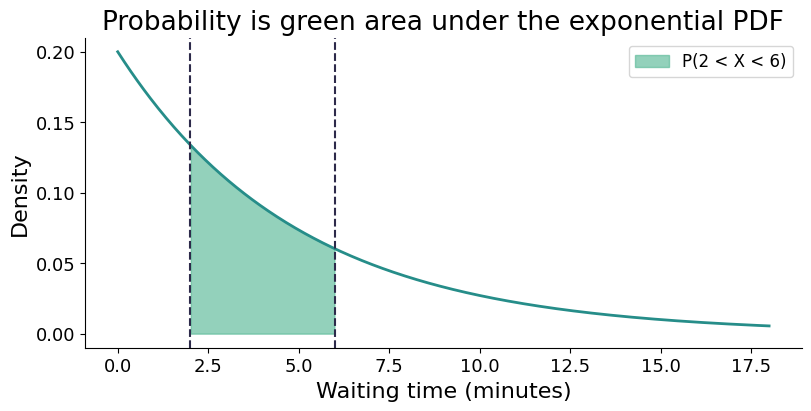

CDF difference: F(6) - F(2) = 0.3691
PDF integral = 0.3691


In [34]:
# Question 4 solution: green area under the exponential PDF
left, right, rate = 2, 6, 0.2
wait = stats.expon(scale=1 / rate)
probability_cdf = wait.cdf(right) - wait.cdf(left)
probability_integral = np.exp(-rate*left) - np.exp(-rate*right)

x_grid = np.linspace(0, 18, 500)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_grid, wait.pdf(x_grid), color="#268D89", lw=2)
mask = (x_grid >= left) & (x_grid <= right)
ax.fill_between(x_grid[mask], wait.pdf(x_grid[mask]), color="#59B997", alpha=0.65,
                label=f"P({left} < X < {right})")
ax.axvline(left, color="#2D2A4A", ls="--")
ax.axvline(right, color="#2D2A4A", ls="--")
ax.set(title="Probability is green area under the exponential PDF",
       xlabel="Waiting time (minutes)", ylabel="Density")
ax.legend(fontsize=12)
plt.show()
print(f"CDF difference: F({right}) - F({left}) = {probability_cdf:.4f}")
print(f"PDF integral = {probability_integral:.4f}")


## 3. Joint and Marginal Distributions

---

### Joint distributions can take several forms

| Pair of variables | Distribution type | Example |
|---|---|---|
| $X=$ submitted a homework, $Y=$ attended lab | Discrete joint PMF | $P(X=1,Y=1)$ |
| $X=$ study time, $Y=$ commute time | Continuous joint PDF | $f_{X,Y}(x,y)$ |

A **marginal** distribution removes the other variable:

$$P(X = x)=\sum_y P(X = x, Y = y),\qquad
f(x)=\int f_{X,Y}(x,y)\,dy.$$

### Example 5: Class-engagement

- $X=0$ if a student didn't submit a practice exercise, $X=1$ if the student submitted late, and $X=2$ if the student submitted on time.
- $Y=1$ if the student attended lab and $Y=0$ otherwise.

Joint PMF table:

| | $Y=0$ (did not attend) | $Y=1$ (attended) |
|---|---:|---:|
| $X=0$ (did not submit) | 0.10 | 0.15 |
| $X=1$ (submitted late) | 0.10 | 0.20 |
| $X=2$ (submitted on time) | 0.20 | 0.25 |

### Questions

1. Is this a valid PMF?
2. Find the marginal probabilities $P(X=1)$ and $P(Y=1)$.
3. Find $P(X=1,Y=1)$.
4. Find $P(X=1\mid Y=1)$.

In [41]:
# Example 5 solution
joint_pmf = pd.DataFrame(
    [[0.10, 0.15], [0.10, 0.2], [0.20, 0.25]],
    index=pd.Index([0, 1, 2], name="X: submission"),
    columns=pd.Index([0, 1], name="Y: attended"),
)
display(joint_pmf)
print(f"Total probability = {joint_pmf.to_numpy().sum():.2f}")
print(f"P(X=1) = {joint_pmf.loc[1].sum():.2f}")
print(f"P(Y=1) = {joint_pmf[1].sum():.2f}")
print(f"P(X=1, Y=1) = {joint_pmf.loc[1, 1]:.2f}")
print(f"P(X=1 | Y=1) = {joint_pmf.loc[1, 1] / joint_pmf[1].sum():.4f}")


Y: attended,0,1
X: submission,,
0,0.1,0.15
1,0.1,0.20
2,0.2,0.25


Total probability = 1.00
P(X=1) = 0.30
P(Y=1) = 0.60
P(X=1, Y=1) = 0.20
P(X=1 | Y=1) = 0.3333


## 4. Expectation and Variance

---

### A parameter of a distribution

For discrete $X$:

$$
\mathbb E[X]=\sum_x x\,P(X = x)
$$
$$
\operatorname{Var}(X)=\mathbb E[(X - \mathbb E[X])^2]=\sum_x(x-\mathbb E[X])^2P(X = x).
$$

Equivalently,

$$\operatorname{Var}(X)=\mathbb E[X^2]-\mathbb E[X]^2,\qquad
\operatorname{SD}(X)=\sqrt{\operatorname{Var}(X)}.$$

For continuous $X$:
$$
\mathbb E[X]=\int_{-\infty}^{\infty} xf(x) dx
$$
$$
\operatorname{Var}(X)=\mathbb E[(X - \mathbb E[X])^2]=\int_{-\infty}^{\infty}(x-\mathbb E[X])^2f(x)dx.
$$


In [35]:
# Exact expectation and variance of a fair die
fair_pmf = np.full(6, 1/6)
fair_mean = np.sum(faces * fair_pmf)
fair_variance = np.sum((faces - fair_mean)**2 * fair_pmf)
print(f"E[X] for a fair die = {fair_mean:.4f}")
print(f"Var(X) for a fair die = {fair_variance:.4f}")
print(f"SD(X) for a fair die = {np.sqrt(fair_variance):.4f}")


E[X] for a fair die = 3.5000
Var(X) for a fair die = 2.9167
SD(X) for a fair die = 1.7078


### Example 6: Weighted die again

Use the PMF from Example 1.

1. Calculate $\mathbb E[X]$.
2. Calculate $\operatorname{Var}(X)$

In [38]:
# Example 6 solution
weighted_mean = np.sum(faces * weighted_pmf)
weighted_variance = np.sum((faces - weighted_mean)**2 * weighted_pmf)
weighted_second_moment = np.sum(faces**2 * weighted_pmf)
weighted_variance_alt = weighted_second_moment - weighted_mean**2
display(pd.DataFrame({"Fair die": [fair_mean, fair_variance],
                      "Weighted die": [weighted_mean, weighted_variance]},
                     index=["Expectation", "Variance"]))
print(f"E[X²] = {weighted_second_moment:.4f}")
print(f"Variance = {weighted_variance_alt:.4f}")


,Fair die,Weighted die
Expectation,3.5000,3.7778
Variance,2.9167,2.8395


E[X²] = 17.1111
Variance = 2.8395


### Some convenient properties

For constants $a,b$:

$$\mathbb E[a+bX]=a+b\mathbb E[X],\qquad
\operatorname{Var}(a+bX)=b^2\operatorname{Var}(X).$$

**Quick question:** A grading rule replaces a score $X$ with $Z=5+1.1X$.
If $\mathbb E[X]=80$ and $\operatorname{Var}(X)=25$, find $\mathbb E[Z]$ and $\operatorname{Var}(Z)$

In [11]:
# Apply the laws of expectation and variance
mean_X, variance_X = 80, 25
a_shift, b_scale = 5, 1.1
print(f"E[Z] = {a_shift + b_scale * mean_X:.1f}")
print(f"Var(Z) = {b_scale**2 * variance_X:.2f}")


E[Z] = 93.0
Var(Z) = 30.25



### Conditional expectation and variance

Assume the relevant expectations exist and that $g(X)$ and $h(X)$ are functions of the conditioning variable $X$. Conditioning on $X$ treats those functions as known constants.

$$
\mathbb E[g(X)+h(X)Y\mid X]
=g(X)+h(X)\mathbb E[Y\mid X].
$$

Conditional expectation is linear:

$$
\mathbb E[Y+Z\mid X]=\mathbb E[Y\mid X]+\mathbb E[Z\mid X].
$$

It is also monotone: if $Y\leq Z$ always, then

$$
\mathbb E[Y\mid X]\leq\mathbb E[Z\mid X].
$$

For conditional variance,

$$
\operatorname{Var}(Y\mid X)
=\mathbb E[(Y-\mathbb E[Y\mid X])^2\mid X]
=\mathbb E[Y^2\mid X]-(\mathbb E[Y\mid X])^2.
$$

Therefore,

$$
\operatorname{Var}(g(X)+h(X)Y\mid X)
=h(X)^2\operatorname{Var}(Y\mid X).
$$

### Law of iterated expectations

$$
\mathbb E[X]=\mathbb E[\mathbb E[X\mid Y]].
$$

In words: average within each $Y$ group, then average those group means using the probabilities of the groups.



<details>
<summary><strong>Finite discrete proof of the law of iterated expectations</strong></summary>

For finite supports $\mathcal X$ and $\mathcal Y$,

\begin{align}
\mathbb E[\mathbb E(X\mid Y)]
&=\sum_{y\in\mathcal Y}\left[\sum_{x\in\mathcal X}x\,\Pr(X=x\mid Y=y)\right]\Pr(Y=y)\\
&=\sum_{x\in\mathcal X}\sum_{y\in\mathcal Y}x\,\Pr(X=x\mid Y=y)\Pr(Y=y)\\
&=\sum_{x\in\mathcal X}\sum_{y\in\mathcal Y}x\,\Pr(X=x,Y=y)\\
&=\sum_{x\in\mathcal X}x\sum_{y\in\mathcal Y}\Pr(X=x,Y=y)\\
&=\sum_{x\in\mathcal X}x\,\Pr(X=x)\\
&=\mathbb E[X].
\end{align}

</details>


## 5. Covariance and Correlation

---

### Covariance and its properties

$$
\operatorname{Cov}(X,Y)
=\mathbb E[(X-\mathbb E[X])(Y-\mathbb E[Y])]
=\mathbb E[XY]-\mathbb E[X]\mathbb E[Y].
$$

$$
\operatorname{Cov}(X,Y)=\operatorname{Cov}(Y,X),\qquad
\operatorname{Cov}(a+bX,Y)=b\,\operatorname{Cov}(X,Y),
$$

$$
\operatorname{Cov}(X,c)=0,\qquad
\operatorname{Var}(X+Y)=\operatorname{Var}(X)+\operatorname{Var}(Y)+2\operatorname{Cov}(X,Y).
$$

### Covariance by hand

| $X$ | 1 | 2 | 3 | 4 |
|---|---:|---:|---:|---:|
| $Y$ | 2 | 1 | 4 | 2 |

1. Find $\bar X$ and $\bar Y$.
2. Form $(X-\bar X)(Y-\bar Y)$ for every pair.
3. Average the four products.

In [48]:
# Question 7 solution: ddof=0 because the four pairs are equally weighted here.
X = np.array([1, 2, 3, 4])
Y = np.array([2, 1, 4, 2])
print(f"E[X] = ", np.mean(X))
print(f"E[Y] = ", np.mean(Y))
centered_table = pd.DataFrame({
    "X": X, "Y": Y, "X - mean(X)": X - X.mean(), "Y - mean(Y)": Y - Y.mean(),
})
centered_table["Product"] = centered_table["X - mean(X)"] * centered_table["Y - mean(Y)"]
display(centered_table)
cov_xy = np.mean(centered_table["Product"])
cov_alt = np.mean(X * Y) - X.mean() * Y.mean()
print(f"Cov(X, Y), products = {cov_xy:.4f}")
print(f"Cov(X, Y), E[XY] - E[X]E[Y] = {cov_alt:.4f}")


E[X] =  2.5
E[Y] =  2.25


,X,Y,X - mean(X),Y - mean(Y),Product
0,1,2,-1.5,-0.25,0.375
1,2,1,-0.5,-1.25,0.625
2,3,4,0.5,1.75,0.875
3,4,2,1.5,-0.25,-0.375


Cov(X, Y), products = 0.3750
Cov(X, Y), E[XY] - E[X]E[Y] = 0.3750


### Correlation: remove the units

$$
\operatorname{Corr}(X,Y)=
\frac{\operatorname{Cov}(X,Y)}
{\sqrt{\operatorname{Var}(X)\operatorname{Var}(Y)}}.
$$

Correlation is unitless and lies in $[-1,1]$.
Covariance has units, such as “hours $\times$ points,” and changes with measurement scales.

For nonzero $b,d$:

$$\operatorname{Corr}(a+bX,\;c+dY)=\operatorname{sign}(bd)\operatorname{Corr}(X,Y).$$

**Predict:** Convert $X$ from hours to minutes. What happens to covariance with $Y$? What happens to correlation?

In [14]:
# Same relationship, two unit systems
X_hours = np.array([1, 2, 3, 4])
Y_score = np.array([55, 65, 72, 88])
X_minutes = 60 * X_hours

pd.DataFrame({
    "Covariance with score": [
        np.cov(X_hours, Y_score, ddof=0)[0, 1],
        np.cov(X_minutes, Y_score, ddof=0)[0, 1],
    ],
    "Correlation with score": [
        np.corrcoef(X_hours, Y_score)[0, 1],
        np.corrcoef(X_minutes, Y_score)[0, 1],
    ],
}, index=["Study hours", "Study minutes"])


,Covariance with score,Correlation with score
Study hours,13.25,0.9859
Study minutes,795.00,0.9859


## 6. Correlation, Independence, and Causation

---

### Three ideas to keep distinct

- **Independence:** learning $X$ gives no information about $Y$. For every pair of events $A,B$,

  $$P(X\in A,\,Y\in B)=P(X\in A)P(Y\in B).$$

  Equivalently, for every event $B$,

  $$P(Y\in B\mid X)=P(Y\in B),$$

  and symmetrically $P(X\in A\mid Y)=P(X\in A)$.

  For continuous variables with a joint PDF, independence is equivalently expressed by

  $$f_{X,Y}(x,y)=f_X(x)f_Y(y)$$

  for all relevant $x,y$ (more precisely, almost everywhere). Equivalently,

  $$f_{Y\mid X}(y\mid x)=f_Y(y)$$

  wherever $f_X(x)>0$, and symmetrically for $f_{X\mid Y}$. With finite variances, independence implies $\operatorname{Cov}(X,Y)=0$.
- **Uncorrelatedness:** $\operatorname{Cov}(X,Y)=0$. This rules out linear association but not all dependence.
- **Causation:** changing $X$ changes $Y$ under an intervention. It needs a causal design or identifying assumptions.

**Question:** If $Y=X^2$ and $X$ is symmetric around zero, are $X$ and $Y$ independent? What might their correlation be?

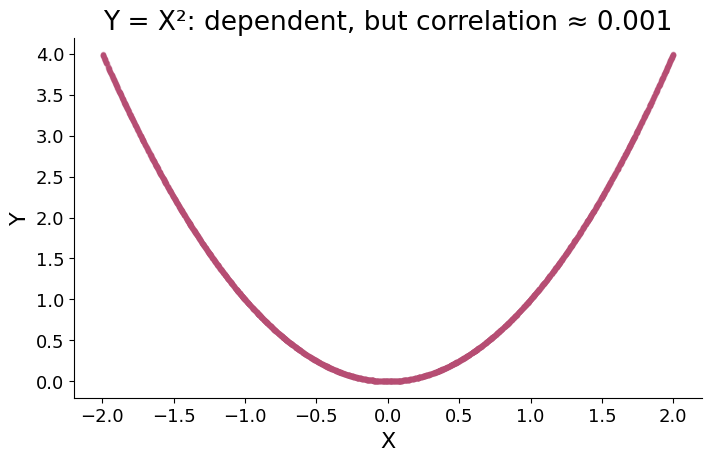

In [15]:
# A dependent but uncorrelated nonlinear relationship
rng = np.random.default_rng(42)
X_curve = rng.uniform(-2, 2, 5_000)
Y_curve = X_curve**2
correlation_curve = np.corrcoef(X_curve, Y_curve)[0, 1]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(X_curve, Y_curve, s=9, alpha=0.25, color="#B64D73")
ax.set(title=f"Y = X²: dependent, but correlation ≈ {correlation_curve:.3f}",
       xlabel="X", ylabel="Y")
plt.show()


### Final discussion: association is not an intervention

Suppose students who spend more time studying tend to have higher scores.

1. Does a positive correlation prove another hour of study will raise every student's score?
2. What variables might affect both study time and score?
3. In the all-causes model, which of those variables could be part of $U$?

Correlation can describe an observed relationship. Causal inference asks what would change under a different state of the world.

### Check your understanding

1. What must be true of a PMF? Of a PDF? Of a CDF?
2. Which distribution would you use for a count of events? For waiting time?
3. How do you calculate $P(a<X<b)$ from a continuous PDF or CDF?
4. How do you get a marginal distribution from a joint distribution?
5. State the law of iterated expectations and one conditional-variance property.
6. State the event-based and joint-PDF criteria for independence.
7. Can dependent variables have zero correlation?

> Expectations define causal parameters such as $\mathbb E[Y(1)-Y(0)]$.
> Assumptions about joint distributions and independence help identify them.